In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path("..")

TRAIN_CSV = PROJECT_DIR / "data" / "raw" / "train.csv"
TRAIN_IMAGES_DIR = PROJECT_DIR / "data" / "raw" / "train_images"

df = pd.read_csv(TRAIN_CSV)

df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [2]:
# Informações gerais do dataframe
print(df.info())

# Quantidade de linhas e colunas
print("Dimensão do train.csv:", df.shape)

# Conferir nomes das colunas
print("Colunas:", df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id_code    3662 non-null   str  
 1   diagnosis  3662 non-null   int64
dtypes: int64(1), str(1)
memory usage: 57.3 KB
None
Dimensão do train.csv: (3662, 2)
Colunas: ['id_code', 'diagnosis']


In [3]:
class_names = {
    0: "Sem retinopatia",
    1: "Retinopatia leve",
    2: "Retinopatia moderada",
    3: "Retinopatia severa",
    4: "Retinopatia proliferativa"
}

df["diagnosis_name"] = df["diagnosis"].map(class_names)

df.head()

,id_code,diagnosis,diagnosis_name
0,000c1434d8d7,2,Retinopatia moderada
1,001639a390f0,4,Retinopatia proliferativa
2,0024cdab0c1e,1,Retinopatia leve
3,002c21358ce6,0,Sem retinopatia
4,005b95c28852,0,Sem retinopatia


In [4]:
class_distribution = (
    df["diagnosis"]
    .value_counts()
    .sort_index()
    .reset_index()
)

class_distribution.columns = ["classe", "quantidade"]
class_distribution["descricao"] = class_distribution["classe"].map(class_names)
class_distribution["percentual"] = (
    class_distribution["quantidade"] / class_distribution["quantidade"].sum() * 100
).round(2)

class_distribution

,classe,quantidade,descricao,percentual
0,0,1805,Sem retinopatia,49.29
1,1,370,Retinopatia leve,10.10
2,2,999,Retinopatia moderada,27.28
3,3,193,Retinopatia severa,5.27
4,4,295,Retinopatia proliferativa,8.06


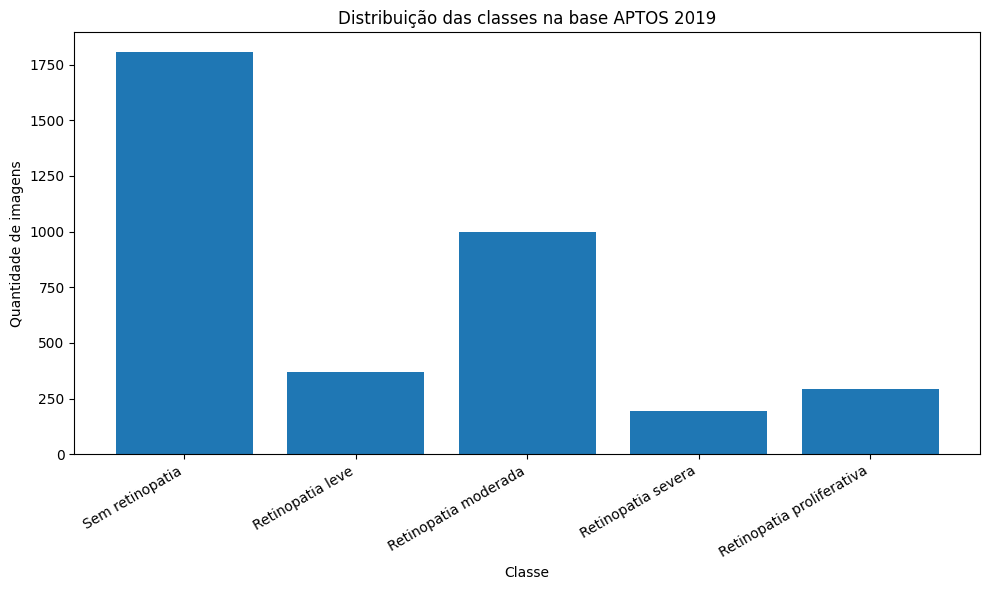

In [5]:
plt.figure(figsize=(10, 6))

plt.bar(
    class_distribution["descricao"],
    class_distribution["quantidade"]
)

plt.title("Distribuição das classes na base APTOS 2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.show()

In [6]:
df["image_path"] = df["id_code"].apply(
    lambda x: TRAIN_IMAGES_DIR / f"{x}.png"
)

df["image_exists"] = df["image_path"].apply(lambda x: x.exists())

total_images_csv = len(df)
existing_images = df["image_exists"].sum()
missing_images = total_images_csv - existing_images

print("Total de registros no train.csv:", total_images_csv)
print("Imagens encontradas:", existing_images)
print("Imagens ausentes:", missing_images)

Total de registros no train.csv: 3662
Imagens encontradas: 3662
Imagens ausentes: 0


In [7]:
df_missing = df[df["image_exists"] == False]

df_missing

,id_code,diagnosis,diagnosis_name,image_path,image_exists


In [8]:
RESULTS_DIR = PROJECT_DIR / "results" / "metrics"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

class_distribution.to_csv(
    RESULTS_DIR / "class_distribution.csv",
    index=False
)

print("Arquivo salvo em:", RESULTS_DIR / "class_distribution.csv")

Arquivo salvo em: ../results/metrics/class_distribution.csv


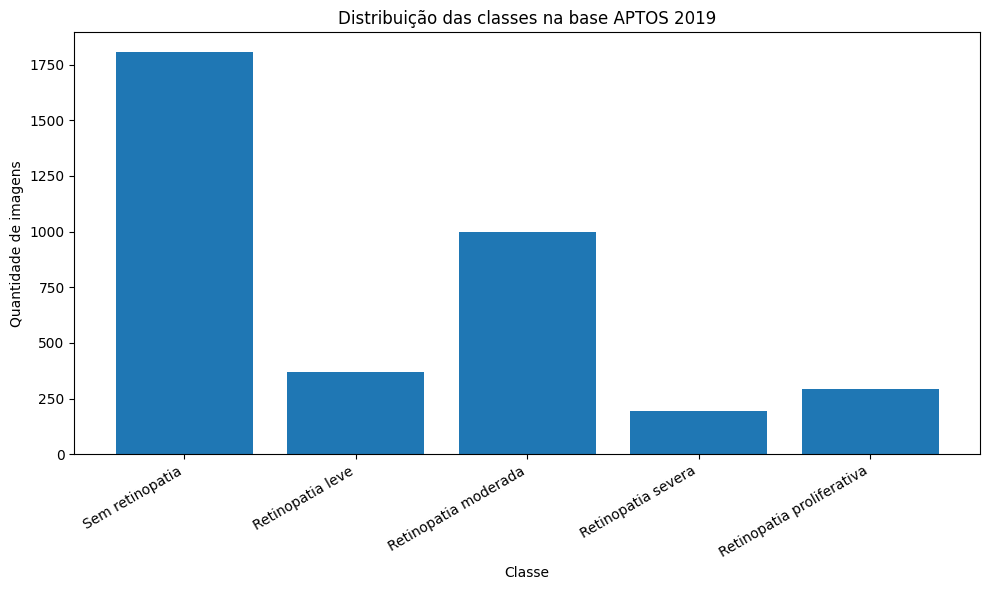

Gráfico salvo em: ../results/figures/class_distribution.png


In [9]:
FIGURES_DIR = PROJECT_DIR / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

plt.bar(
    class_distribution["descricao"],
    class_distribution["quantidade"]
)

plt.title("Distribuição das classes na base APTOS 2019")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=300)
plt.show()

print("Gráfico salvo em:", FIGURES_DIR / "class_distribution.png")

In [10]:
import pandas as pd
from pathlib import Path

PROJECT_DIR = Path("..")
SPLITS_DIR = PROJECT_DIR / "data" / "splits"

train_df = pd.read_csv(SPLITS_DIR / "train_split.csv")
test_df = pd.read_csv(SPLITS_DIR / "test_split.csv")

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

print("\nDistribuição treino:")
print(train_df["diagnosis"].value_counts(normalize=True).sort_index() * 100)

print("\nDistribuição teste:")
print(test_df["diagnosis"].value_counts(normalize=True).sort_index() * 100)

Treino: (2197, 3)
Teste: (1465, 3)

Distribuição treino:
diagnosis
0    49.294492
1    10.104688
2    27.264452
3     5.279927
4     8.056441
Name: proportion, dtype: float64

Distribuição teste:
diagnosis
0    49.283276
1    10.102389
2    27.303754
3     5.255973
4     8.054608
Name: proportion, dtype: float64
